# Case study: euro yield-curve dynamics, forecasting and interest-rate risk in the banking book

**Business question.** The asset-liability committee (ALCO) of a euro area retail bank asks two things of its treasury:

1. *Can we forecast the yield curve well enough to steer the balance sheet on a view?* If not, the committee should manage
   interest-rate risk with scenarios rather than point forecasts.
2. *How much economic value does the bank lose in the supervisory interest-rate shocks, does it breach the EBA outlier tests,
   and which swap hedge brings it within limits at an acceptable cost in net interest income?*

**Data.** Daily Svensson parameters of the **ECB euro area yield curve (AAA-rated central government bonds)**, September 2004 -
December 2025, sampled at month ends, giving continuously compounded zero rates at 11 maturities from 3 months to 30 years.

**Methods.**

| step | method | reference |
| --- | --- | --- |
| factor structure | principal components of monthly yield changes | Litterman and Scheinkman (1991) |
| dynamic Nelson-Siegel, two-step | cross-sectional OLS with fixed decay, then AR(1)/VAR(1) factors | Diebold and Li (2006) |
| dynamic Nelson-Siegel, one-step | state-space model, exact Gaussian likelihood by the Kalman filter (C++), maximum likelihood | Diebold, Rudebusch and Aruoba (2006) |
| forecast evaluation | recursive out-of-sample forecasts, Diebold-Mariano tests with small-sample correction | Diebold and Mariano (1995); Harvey, Leybourne and Newbold (1997) |
| IRRBB | change in economic value of equity (EVE) under the six standardised shocks, post-shock floor, supervisory outlier tests on EVE and NII | BCBS (2016); EBA/GL/2022/14; EBA/RTS/2022/10 |
| hedging | minimax swap overlay by linear programming under an NII constraint | this notebook |

**Conventions.** Yields in percent (factor models) or decimals (IRRBB), continuously compounded; maturities and times in years;
amounts in EUR million. The ECB AAA government curve is used as the risk-free curve; a bank would normally use its €STR swap
curve, which lies a few basis points to a few tens of basis points away from it.

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "quant_engine").is_dir())
try:
    import quant_engine
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "quant_engine"))
    import quant_engine
from quant_engine import banking_book, data, synthetic
from quant_engine import term_structure as ts
from quant_engine.curves import SvenssonCurve

core = quant_engine.require_cpp()

DATA_MODE = os.environ.get("QUANT_ENGINE_DATA_MODE", "official")  # "official" (ECB) or "synthetic" (offline)
START, END = "2004-09-01", "2025-12-31"      # full history of the ECB yield curve dataset
MATURITIES = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30])   # years
SHOW = [0.25, 1.0, 2.0, 5.0, 10.0, 30.0]
FIRST_ORIGIN = "2014-12-31"                   # first forecast origin: out-of-sample targets 2015-2025
HORIZONS = (1, 6, 12)                         # months
REFIT_EVERY = 12                              # months between re-estimations of the state-space model
OUTPUT_DIR = ROOT / "outputs" / "yield_curve_irrbb"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print(f"quant_engine {quant_engine.__version__} | data mode: {DATA_MODE}")

quant_engine 0.1.0 | data mode: official


## 1. Data: month-end zero curves

The ECB publishes the six Svensson parameters every business day; the zero rate at maturity $m$ is
$y(m) = \beta_0 + \beta_1 \frac{1-e^{-m/\tau_1}}{m/\tau_1} + \beta_2\left(\frac{1-e^{-m/\tau_1}}{m/\tau_1} - e^{-m/\tau_1}\right)
+ \beta_3\left(\frac{1-e^{-m/\tau_2}}{m/\tau_2} - e^{-m/\tau_2}\right)$. We take the last curve of each month.

Source: European Central Bank, euro area yield curves (AAA), Svensson parameters
256 month-end curves from September 2004 to December 2025


,0.25y,0.5y,1y,2y,3y,5y,7y,10y,15y,20y,30y
mean (%),0.902,0.923,0.955,1.030,1.136,1.400,1.661,1.976,2.285,2.419,2.464
std (%),1.616,1.628,1.624,1.596,1.578,1.563,1.560,1.562,1.558,1.540,1.489
min (%),-0.928,-0.879,-0.882,-0.930,-0.951,-0.916,-0.820,-0.653,-0.434,-0.313,-0.195
max (%),4.242,4.332,4.494,4.619,4.636,4.627,4.653,4.732,4.847,4.918,4.992
std of monthly change (bp),16.101,16.067,17.206,19.199,19.730,19.908,20.038,20.188,20.448,20.658,21.642
"autocorrelation, 1 month",0.995,0.995,0.994,0.993,0.992,0.992,0.992,0.992,0.991,0.991,0.989
"autocorrelation, 12 months",0.752,0.759,0.781,0.822,0.849,0.875,0.885,0.890,0.890,0.888,0.883


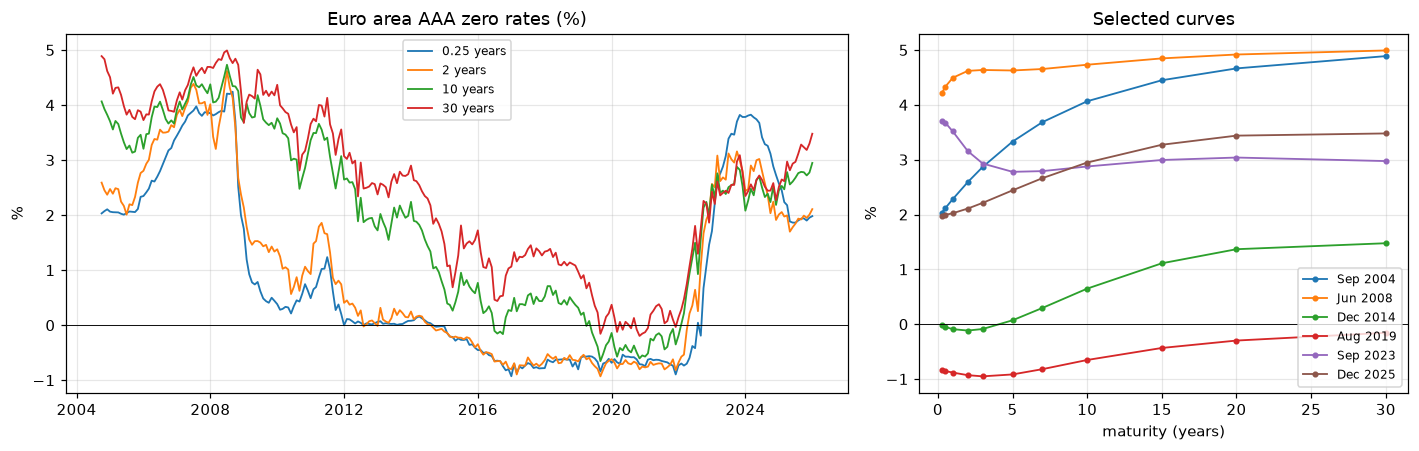

In [2]:
if DATA_MODE == "official":
    svensson = data.load_ecb_svensson_parameters(START, END)
else:
    svensson = synthetic.svensson_history(START, END)
print("Source:", svensson.attrs.get("source"))
monthly = svensson.resample("ME").last().dropna()
Y = ts.zero_curves(svensson, MATURITIES)
print(f"{len(Y)} month-end curves from {Y.index[0]:%B %Y} to {Y.index[-1]:%B %Y}")

summary = pd.DataFrame({
    "mean (%)": Y.mean(), "std (%)": Y.std(), "min (%)": Y.min(), "max (%)": Y.max(),
    "std of monthly change (bp)": 100 * Y.diff().std(),
    "autocorrelation, 1 month": Y.apply(lambda s: s.autocorr(1)),
    "autocorrelation, 12 months": Y.apply(lambda s: s.autocorr(12)),
})
summary.index = [f"{m:g}y" for m in MATURITIES]
display(summary.T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
for m in (0.25, 2.0, 10.0, 30.0):
    axes[0].plot(Y.index, Y[m], lw=1.2, label=f"{m:g} years")
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set(title="Euro area AAA zero rates (%)", ylabel="%")
axes[0].legend(fontsize=8)
for d in ("2004-09-30", "2008-06-30", "2014-12-31", "2019-08-31", "2023-09-30", "2025-12-31"):
    row = Y.loc[:d].iloc[-1]
    axes[1].plot(MATURITIES, row.to_numpy(), marker="o", ms=3, lw=1.2, label=f"{row.name:%b %Y}")
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set(title="Selected curves", xlabel="maturity (years)", ylabel="%")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "zero_curves.png", dpi=150)

## 2. Principal components of yield changes

PCA of the covariance matrix of monthly changes (basis points). Signs are fixed so that the first component raises all yields,
the second raises long yields relative to short ones, and the third raises the middle of the curve. The Nelson-Siegel loadings
with the Diebold-Li decay are shown for comparison: if the three statistical factors look like level, slope and curvature,
a three-factor Nelson-Siegel model is a parsimonious description of the curve.

,share of variance,cumulative
level,0.756,0.756
slope,0.164,0.920
curvature,0.054,0.975
PC4,0.012,0.986
PC5,0.007,0.994


,level: 3-month / 10-year loading,slope: correlation with NS loading,curvature: correlation with NS loading
PCA vs Nelson-Siegel,0.351,0.968,0.878


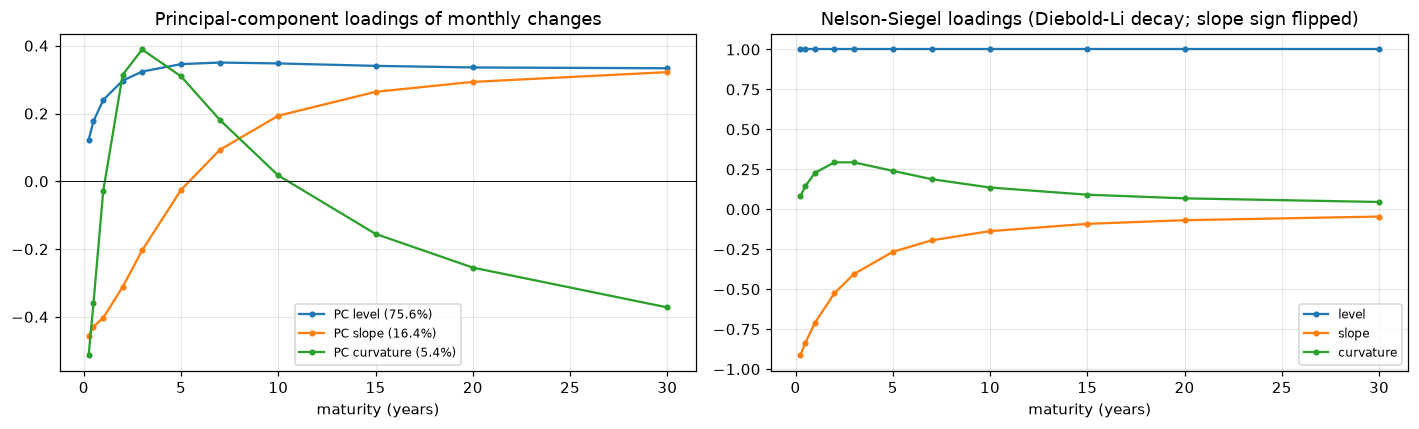

In [3]:
dY = 100 * Y.diff().dropna()
pca = ts.principal_components(dY, n=3)
explained = pca["explained"].head(5).to_frame()
explained["cumulative"] = explained["share of variance"].cumsum()
display(explained)

ns = pd.DataFrame(ts.ns_loadings(MATURITIES), index=MATURITIES, columns=["level", "slope", "curvature"])
ns["slope"] = -ns["slope"]   # Nelson-Siegel slope factor = short minus long; flip to 'long minus short'
level = pca["loadings"]["level"]
display(pd.Series({"level: 3-month / 10-year loading": level[0.25] / level[10.0],
                   "slope: correlation with NS loading": np.corrcoef(pca["loadings"]["slope"], ns["slope"])[0, 1],
                   "curvature: correlation with NS loading": np.corrcoef(pca["loadings"]["curvature"], ns["curvature"])[0, 1]},
                  name="PCA vs Nelson-Siegel").to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for k in ("level", "slope", "curvature"):
    axes[0].plot(MATURITIES, pca["loadings"][k], marker="o", ms=3, label=f"PC {k} ({100 * pca['explained'][k]:.1f}%)")
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set(title="Principal-component loadings of monthly changes", xlabel="maturity (years)")
axes[0].legend(fontsize=8)
for k in ns:
    axes[1].plot(MATURITIES, ns[k], marker="o", ms=3, label=k)
axes[1].set(title="Nelson-Siegel loadings (Diebold-Li decay; slope sign flipped)", xlabel="maturity (years)")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pca_loadings.png", dpi=150)

## 3. Dynamic Nelson-Siegel, two-step estimation

$y_t(m) = \beta_{1t} + \beta_{2t}\frac{1-e^{-\lambda m}}{\lambda m} + \beta_{3t}\left(\frac{1-e^{-\lambda m}}{\lambda m} - e^{-\lambda m}\right) + \varepsilon_t(m)$.
With $\lambda$ fixed at the Diebold-Li value ($0.0609$ per month, curvature loading peaking at 30 months) the factors are
OLS estimates date by date. The factors should track their empirical counterparts: level vs the 10-year yield, slope
($\beta_2$ = short minus long) vs the 3-month minus 10-year spread, curvature vs $2y(2) - y(0.25) - y(10)$.

In [4]:
F2 = ts.fit_ns_cross_section(Y)
fitted = F2.to_numpy() @ ts.ns_loadings(MATURITIES).T
rmse_fit = pd.Series(100 * np.sqrt(((Y.to_numpy() - fitted) ** 2).mean(axis=0)), index=[f"{m:g}y" for m in MATURITIES],
                     name="two-step fit RMSE (bp)")
display(rmse_fit.to_frame().T)
proxies = pd.DataFrame({"level": Y[10.0], "slope": Y[0.25] - Y[10.0], "curvature": 2 * Y[2.0] - Y[0.25] - Y[10.0]})
display(pd.Series({k: F2[k].corr(proxies[k]) for k in F2}, name="correlation with empirical proxy").to_frame().T)
var2 = ts.fit_var1(F2.to_numpy())
display(pd.DataFrame(var2["A"], index=F2.columns, columns=[f"{c} (t-1)" for c in F2.columns]).round(3))
print("VAR(1) eigenvalue moduli:", np.round(np.abs(np.linalg.eigvals(var2["A"])), 4))

,0.25y,0.5y,1y,2y,3y,5y,7y,10y,15y,20y,30y
two-step fit RMSE (bp),9.970,2.964,11.236,10.006,3.246,11.914,13.585,8.917,8.859,9.604,14.020


,level,slope,curvature
correlation with empirical proxy,0.973,0.995,0.947


,level (t-1),slope (t-1),curvature (t-1)
level,0.988,-0.003,0.029
slope,-0.008,0.957,0.024
curvature,-0.015,0.044,0.921


VAR(1) eigenvalue moduli: [0.9811 0.9811 0.904 ]


## 4. State-space DNS by maximum likelihood (C++ Kalman filter)

Measurement: $y_t = \Lambda(\lambda) f_t + e_t$, $e_t \sim N(0, \operatorname{diag}(h_1^2,\dots,h_{11}^2))$.
Transition: $f_t - \mu = A (f_{t-1} - \mu) + u_t$, $u_t \sim N(0, Q)$, with $Q$ parameterised by its Cholesky factor.
The filter starts from the unconditional distribution of the factors. All parameters, including $\lambda$, are estimated
jointly, so factor uncertainty is propagated and the decay is chosen by the data rather than fixed.

**Identification issue.** With a free measurement variance at each maturity (31 parameters) the likelihood has a degenerate
optimum: three factors can reproduce three maturities exactly, so the optimiser drives three measurement standard deviations
towards zero and the likelihood keeps rising. The ECB yields are themselves smooth Svensson fits, which makes this
especially easy. We show the degenerate fit and then use a **common measurement standard deviation** across maturities
(20 parameters), whose optimum is a proper interior maximum.

Because the measurement covariance is diagonal, the C++ filter updates with the Woodbury identity and needs only
3 x 3 factorisations per month; it is checked against the textbook NumPy implementation, which is itself tested against
the joint Gaussian density of all observations. Standard errors come from the inverse numerical Hessian.

numpy: log-likelihood 1,286.474736 in 34.00 ms
  cpp: log-likelihood 1,286.474736 in 0.26 ms
C++ speed-up: 132x


,log-likelihood,converged (central gradient < 0.01),lambda,smallest h (bp),maturities with h < 1 bp,seconds
free h by maturity,"2,726.072",False,0.429,0.242,"0.5y, 5y, 15y",4.546
common h,"1,907.332",True,0.492,8.942,-,1.905


common-h model: all standard errors finite: True; measurement s.d. 8.9 bp
lambda = 0.4922 per year (s.e. 0.0057); curvature loading peaks at 44 months (Diebold-Li: 30)


,estimate,s.e.,t-stat
mu level,3.259,0.768,4.243
mu slope,-1.915,0.624,-3.067
mu curvature,-2.211,0.310,-7.130
A level<-level,0.991,0.008,117.570
A level<-slope,0.010,0.010,0.946
A level<-curvature,0.031,0.010,3.068
A slope<-level,-0.013,0.010,-1.275
A slope<-slope,0.970,0.013,75.609
A slope<-curvature,0.016,0.013,1.204
A curvature<-level,-0.012,0.020,-0.603


,slowest,middle,fastest
half-life of factor modes (months),37.115,37.115,10.970


,monthly shock s.d. (bp),correlation with level shock
level,20.266,1.000
slope,25.620,-0.770
curvature,46.150,-0.004


,0.25y,0.5y,1y,2y,3y,5y,7y,10y,15y,20y,30y
filtered fit RMSE (bp),7.817,3.467,7.755,7.354,5.069,5.356,6.651,8.070,9.232,5.942,14.770


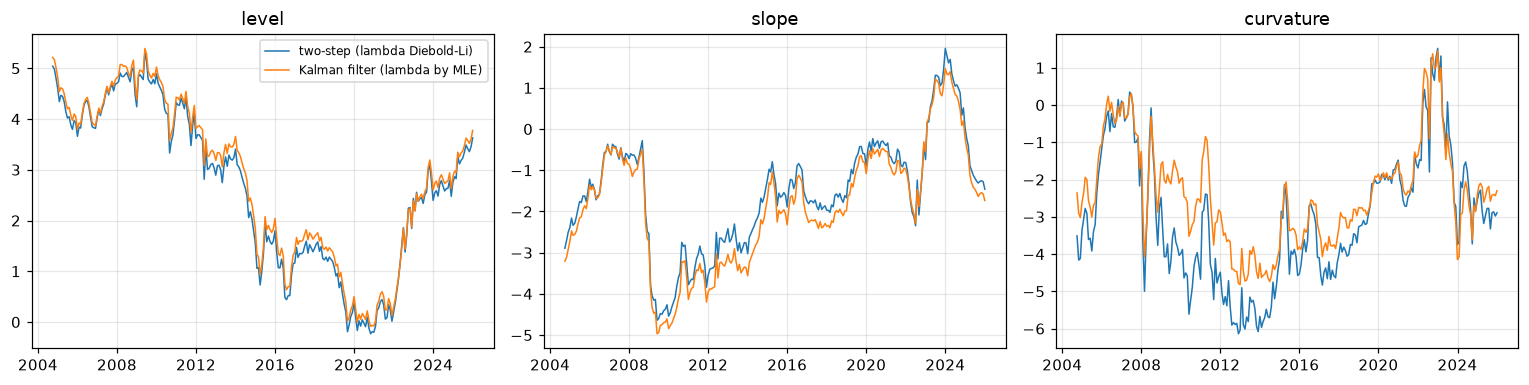

In [5]:
start_model = ts.DNSModel(ts.DIEBOLD_LI_LAMBDA, F2.mean().to_numpy(), var2["A"], var2["Sigma"],
                          np.full(MATURITIES.size, 0.1), MATURITIES)
timings = {}
for engine in ("numpy", "cpp"):
    t0 = time.perf_counter()
    for _ in range(20):
        ll = ts.kalman_filter(start_model, Y.to_numpy(), engine=engine, keep_states=False)["loglik"]
    timings[engine] = (time.perf_counter() - t0) / 20
    print(f"{engine:>5}: log-likelihood {ll:,.6f} in {1e3 * timings[engine]:.2f} ms")
print(f"C++ speed-up: {timings['numpy'] / timings['cpp']:.0f}x")

t0 = time.perf_counter()
free_h = ts.fit_dns_kalman(Y)
t1 = time.perf_counter()
dns = ts.fit_dns_kalman(Y, common_h=True)
t2 = time.perf_counter()
display(pd.DataFrame({
    "log-likelihood": [free_h.loglik, dns.loglik],
    "converged (central gradient < 0.01)": [free_h.converged, dns.converged],
    "lambda": [free_h.lam, dns.lam],
    "smallest h (bp)": [100 * free_h.h.min(), 100 * dns.h.min()],
    "maturities with h < 1 bp": [", ".join(f"{m:g}y" for m, v in zip(MATURITIES, free_h.h) if v < 0.01) or "-", "-"],
    "seconds": [t1 - t0, t2 - t1]}, index=["free h by maturity", "common h"]))
se = ts.dns_standard_errors(dns, Y)
H_ok = np.all(np.isfinite(se.to_numpy()))
print(f"common-h model: all standard errors finite: {H_ok}; measurement s.d. {100 * dns.h[0]:.1f} bp")
names = ["level", "slope", "curvature"]
peak_months = 12 * 1.7932 / dns.lam   # the curvature loading peaks at lambda * m = 1.7932
print(f"lambda = {dns.lam:.4f} per year (s.e. {dns.lam * se['log lambda']:.4f}); "
      f"curvature loading peaks at {peak_months:.0f} months (Diebold-Li: 30)")
params = pd.DataFrame({"estimate": dns.A.ravel(), "s.e.": [se[f"A {a}<-{b}"] for a in names for b in names]},
                      index=[f"A {a}<-{b}" for a in names for b in names])
params = pd.concat([pd.DataFrame({"estimate": dns.mu, "s.e.": [se[f"mu {a}"] for a in names]},
                                 index=[f"mu {a}" for a in names]), params])
params["t-stat"] = params["estimate"] / params["s.e."]
display(params)
eig = np.abs(np.linalg.eigvals(dns.A))
half_lives = pd.Series(np.log(0.5) / np.log(np.sort(eig)[::-1]), index=["slowest", "middle", "fastest"],
                       name="half-life of factor modes (months)")
display(half_lives.to_frame().T)
vol = pd.DataFrame(np.sqrt(np.diag(dns.Q)) * 100, index=names, columns=["monthly shock s.d. (bp)"])
vol["correlation with level shock"] = dns.Q[:, 0] / np.sqrt(np.diag(dns.Q) * dns.Q[0, 0])
display(vol)
kf = ts.kalman_filter(dns, Y.to_numpy())
fit_err = Y.to_numpy() - kf["filtered"] @ ts.ns_loadings(MATURITIES, dns.lam).T
display(pd.Series(100 * np.sqrt((fit_err ** 2).mean(axis=0)), index=[f"{m:g}y" for m in MATURITIES],
                  name="filtered fit RMSE (bp)").to_frame().T)
Ff = pd.DataFrame(kf["filtered"], index=Y.index, columns=names)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, k in zip(axes, names):
    ax.plot(F2.index, F2[k], lw=1.0, label="two-step (lambda Diebold-Li)")
    ax.plot(Ff.index, Ff[k], lw=1.0, label="Kalman filter (lambda by MLE)")
    ax.set(title=k)
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dns_factors.png", dpi=150)

## 5. Out-of-sample forecasts, 2015-2025

At each month-end origin from December 2014 the models are estimated on data up to that month only (expanding window)
and forecast the curve 1, 6 and 12 months ahead:

* **random walk**: no change (the benchmark that is notoriously hard to beat);
* **DNS AR(1), direct**: Diebold-Li two-step, each factor regressed directly on its value $h$ months earlier;
* **DNS VAR(1)**: two-step factors, iterated VAR(1);
* **DNS state space**: one-step MLE (common measurement error), re-estimated every 12 months, state filtered every month.

Accuracy is the root mean squared error in basis points. The Diebold-Mariano statistic compares squared errors with the
random walk (negative values favour the model); with overlapping $h$-month forecasts the variance uses $h-1$ autocovariances and
the Harvey-Leybourne-Newbold small-sample correction. Tests at the 5% level on 11 maturities x 3 horizons x 3 models are many
tests, so isolated rejections should be read with care.

In [6]:
t0 = time.perf_counter()
fc = ts.recursive_forecasts(Y, FIRST_ORIGIN, HORIZONS)
kfc = ts.recursive_kalman_forecasts(Y, FIRST_ORIGIN, HORIZONS, refit_every=REFIT_EVERY, common_h=True)
print(f"forecasts computed in {time.perf_counter() - t0:.1f} s; "
      f"{len(kfc['fits'])} maximum-likelihood re-estimations, all converged: {kfc['fits']['converged'].all()}")
display(kfc["fits"][["lambda", "loglik"]].T)
errors = {h: {**fc[h], "DNS state space": kfc[h].loc[fc[h]["random walk"].index]} for h in HORIZONS}
MODELS = list(errors[1])

def rmse(e):
    return 100 * np.sqrt((e ** 2).mean())

rows = []
for h in HORIZONS:
    for model in MODELS:
        r = rmse(errors[h][model])[SHOW]
        rows.append(pd.Series(r.to_numpy(), index=[f"{m:g}y" for m in SHOW], name=(h, model)))
table = pd.DataFrame(rows)
table.index = pd.MultiIndex.from_tuples(table.index, names=["horizon (months)", "model"])
print(f"RMSE (bp); targets {errors[1]['random walk'].index[0]:%b %Y} - {errors[1]['random walk'].index[-1]:%b %Y}")
display(table.round(1))

def stars(p):
    return "**" if p < 0.01 else "*" if p < 0.05 else ""

dm_rows = []
for h in HORIZONS:
    for model in MODELS[1:]:
        row = {}
        for m in SHOW:
            res = ts.diebold_mariano(errors[h][model][m], errors[h]["random walk"][m], horizon=h)
            row[f"{m:g}y"] = f"{res['statistic']:+.2f}{stars(res['p_value'])}"
        dm_rows.append(pd.Series(row, name=(h, model)))
dm = pd.DataFrame(dm_rows)
dm.index = pd.MultiIndex.from_tuples(dm.index, names=["horizon (months)", "model vs random walk"])
print("Diebold-Mariano statistics (negative = model more accurate; * 5%, ** 1%)")
display(dm)

forecasts computed in 15.0 s; 11 maximum-likelihood re-estimations, all converged: True


origin,2014-12-31,2015-12-31,2016-12-31,2017-12-31,2018-12-31,2019-12-31,2020-12-31,2021-12-31,2022-12-31,2023-12-31,2024-12-31
lambda,0.561,0.541,0.522,0.507,0.504,0.495,0.489,0.485,0.488,0.486,0.491
loglik,736.816,821.014,911.724,"1,030.983","1,171.023","1,292.269","1,419.916","1,556.946","1,597.477","1,675.424","1,783.569"


RMSE (bp); targets Jan 2015 - Dec 2025


0.25y      1y      2y      5y     10y  \
horizon (months) model                                                       
1                random walk        15.100  15.700  17.900  19.700  20.300   
                 DNS AR(1), direct  15.300  22.400  22.200  22.600  22.800   
                 DNS VAR(1)         16.700  19.100  19.800  23.900  23.600   
                 DNS state space    17.600  19.300  18.800  22.100  22.600   
6                random walk        65.800  61.900  55.200  48.200  48.700   
                 DNS AR(1), direct  69.200  75.900  68.300  54.300  54.400   
                 DNS VAR(1)         58.400  59.200  55.400  53.200  51.300   
                 DNS state space    71.500  69.000  63.200  60.600  56.900   
12               random walk       120.300 110.600  97.600  83.200  81.000   
                 DNS AR(1), direct 135.600 139.100 126.200  99.300  93.300   
                 DNS VAR(1)        109.400 108.100 100.800  91.500  85.700   
                 DNS state space   129.400 124.100 116.100 109.000 101.500   

                                      30y  
horizon (months) model                     
1                random walk       21.500  
                 DNS AR(1), direct 24.300  
                 DNS VAR(1)        22.700  
                 DNS state space   20.900  
6                random walk       50.400  
                 DNS AR(1), direct 56.800  
                 DNS VAR(1)        46.400  
                 DNS state space   48.200  
12               random walk       77.300  
                 DNS AR(1), direct 90.500  
                 DNS VAR(1)        74.500  
                 DNS state space   86.500

Diebold-Mariano statistics (negative = model more accurate; * 5%, ** 1%)


0.25y       1y       2y       5y  \
horizon (months) model vs random walk                                     
1                DNS AR(1), direct     +0.18  +4.70**  +5.52**  +3.99**   
                 DNS VAR(1)            +1.03  +3.89**  +3.19**  +3.87**   
                 DNS state space       +1.31  +3.02**    +1.27   +2.55*   
6                DNS AR(1), direct     +0.84    +1.77   +1.98*    +1.67   
                 DNS VAR(1)            -0.54    -0.53    +0.06    +0.93   
                 DNS state space       +0.36    +0.79    +1.06    +1.65   
12               DNS AR(1), direct     +1.13    +1.55    +1.58    +1.35   
                 DNS VAR(1)            -0.45    -0.23    +0.43    +0.69   
                 DNS state space       +0.26    +0.53    +0.81    +1.17   

                                           10y     30y  
horizon (months) model vs random walk                   
1                DNS AR(1), direct     +3.67**  +2.56*  
                 DNS VAR(1)            +3.41**   +1.17  
                 DNS state space       +2.76**   -0.88  
6                DNS AR(1), direct      +2.57*   +1.46  
                 DNS VAR(1)              +0.44   -0.98  
                 DNS state space         +1.36   -0.47  
12               DNS AR(1), direct       +1.50   +1.41  
                 DNS VAR(1)              +0.39   -0.36  
                 DNS state space         +1.15   +0.73

### Forecast accuracy by regime

The evaluation period contains two very different regimes: 2015-2021, with policy rates at or below zero and a flat, anchored
front end; and 2022-2025, with the fastest tightening in the history of the euro and a subsequent easing. Relative RMSE
below 1 means the model beats the random walk.

0.25y    1y  \
regime                            horizon model                            
2015-2021 (negative rates)        1       DNS AR(1), direct  1.640 2.240   
                                          DNS VAR(1)         2.260 1.790   
                                          DNS state space    2.510 1.480   
                                  6       DNS AR(1), direct  1.590 2.880   
                                          DNS VAR(1)         3.190 2.210   
                                          DNS state space    4.720 4.300   
                                  12      DNS AR(1), direct  2.890 3.740   
                                          DNS VAR(1)         3.800 2.980   
                                          DNS state space    6.010 5.560   
2022-2025 (tightening and easing) 1       DNS AR(1), direct  0.840 1.300   
                                          DNS VAR(1)         0.680 1.130   
                                          DNS state space    0.630 1.190   
                                  6       DNS AR(1), direct  1.030 1.160   
                                          DNS VAR(1)         0.720 0.910   
                                          DNS state space    0.770 0.920   
                                  12      DNS AR(1), direct  1.080 1.170   
                                          DNS VAR(1)         0.780 0.910   
                                          DNS state space    0.780 0.880   

                                                               2y    5y   10y  \
regime                            horizon model                                 
2015-2021 (negative rates)        1       DNS AR(1), direct 2.030 1.470 1.280   
                                          DNS VAR(1)        1.630 1.650 1.420   
                                          DNS state space   1.200 1.330 1.280   
                                  6       DNS AR(1), direct 2.540 1.290 1.180   
                                          DNS VAR(1)        1.840 1.840 1.390   
                                          DNS state space   3.550 2.390 1.590   
                                  12      DNS AR(1), direct 3.120 1.390 1.150   
                                          DNS VAR(1)        2.530 2.060 1.530   
                                          DNS state space   4.750 3.050 2.030   
2022-2025 (tightening and easing) 1       DNS AR(1), direct 1.090 1.020 1.020   
                                          DNS VAR(1)        1.020 1.040 0.990   
                                          DNS state space   1.030 1.040 1.010   
                                  6       DNS AR(1), direct 1.160 1.100 1.100   
                                          DNS VAR(1)        0.960 0.960 0.900   
                                          DNS state space   0.950 1.010 0.970   
                                  12      DNS AR(1), direct 1.210 1.170 1.150   
                                          DNS VAR(1)        0.960 0.960 0.910   
                                          DNS state space   0.930 1.000 0.980   

                                                              30y  
regime                            horizon model                    
2015-2021 (negative rates)        1       DNS AR(1), direct 1.240  
                                          DNS VAR(1)        1.130  
                                          DNS state space   0.980  
                                  6       DNS AR(1), direct 1.200  
                                          DNS VAR(1)        0.970  
                                          DNS state space   1.080  
                                  12      DNS AR(1), direct 1.180  
                                          DNS VAR(1)        1.100  
                                          DNS state space   1.460  
2022-2025 (tightening and easing) 1       DNS AR(1), direct 1.010  
                                          DNS VAR(1)        0.970  
                                   

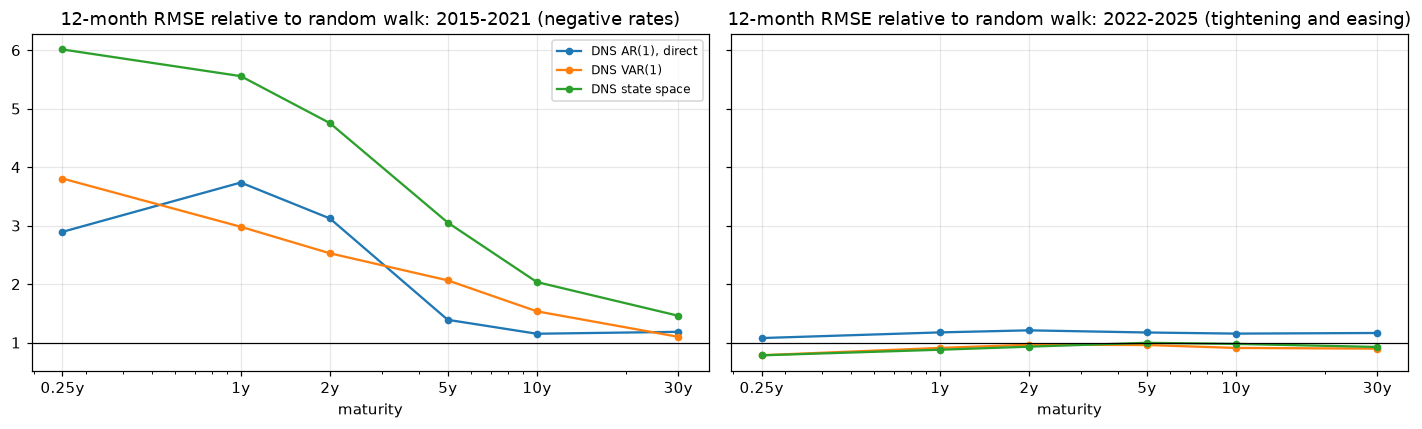

In [7]:
REGIMES = {"2015-2021 (negative rates)": ("2015-01-01", "2021-12-31"), "2022-2025 (tightening and easing)": ("2022-01-01", "2025-12-31")}
rel_rows = []
for regime, (a, b) in REGIMES.items():
    for h in HORIZONS:
        rw = rmse(errors[h]["random walk"].loc[a:b])
        for model in MODELS[1:]:
            r = rmse(errors[h][model].loc[a:b]) / rw
            rel_rows.append(pd.Series(r[SHOW].to_numpy(), index=[f"{m:g}y" for m in SHOW], name=(regime, h, model)))
rel = pd.DataFrame(rel_rows)
rel.index = pd.MultiIndex.from_tuples(rel.index, names=["regime", "horizon", "model"])
display(rel.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, regime in zip(axes, REGIMES):
    sub = rel.xs((regime, 12), level=("regime", "horizon"))
    for model, row in sub.iterrows():
        ax.plot(SHOW, row.to_numpy(), marker="o", ms=4, label=model)
    ax.axhline(1, color="k", lw=0.8)
    ax.set_xscale("log")
    ax.set_xticks(SHOW, [f"{m:g}y" for m in SHOW])
    ax.set(title=f"12-month RMSE relative to random walk: {regime}", xlabel="maturity")
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "forecast_regimes.png", dpi=150)

## 6. Interest-rate risk in the banking book

### 6.1 Base curve, supervisory scenarios and floor

The six BCBS scenarios for the euro use shock sizes of 200 bp (parallel), 250 bp (short) and 100 bp (long):
short-rate shock $S(t) = 250\,e^{-t/4}$ bp, long-rate shock $L(t) = 100\,(1 - e^{-t/4})$ bp, steepener $-0.65|S(t)| + 0.9|L(t)|$,
flattener $+0.8|S(t)| - 0.6|L(t)|$. After the shock, rates are floored at $-150$ bp for the shortest maturity rising by 3 bp a year
to 0% at 50 years (EBA/GL/2022/14), or at the observed rate when that is lower.

Base curve: ECB AAA curve of 31 December 2025


,0.25y,1y,2y,5y,10y,30y
zero rate (%),1.981,2.024,2.108,2.441,2.948,3.479


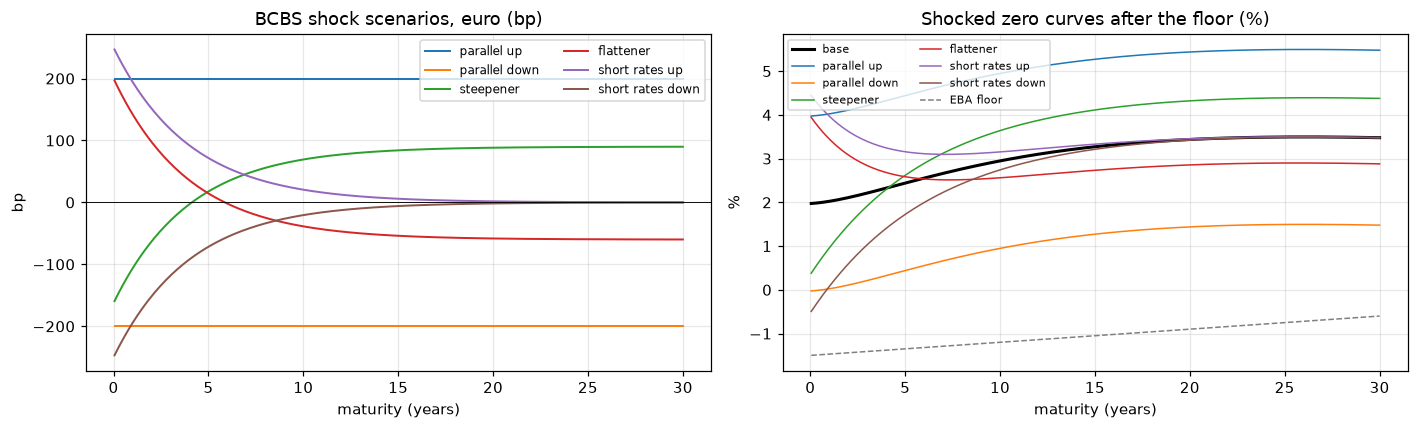

In [8]:
BASE_DATE = svensson.index[-1]
curve = SvenssonCurve.from_series(svensson.iloc[-1])
zero = curve.zero_rate
grid = np.linspace(0.05, 30, 300)
scen = ts.bcbs_scenarios(grid)
print(f"Base curve: ECB AAA curve of {BASE_DATE:%d %B %Y}")
display(pd.Series(100 * zero(np.array(SHOW)), index=[f"{m:g}y" for m in SHOW], name="zero rate (%)").to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, s in scen.items():
    axes[0].plot(grid, 1e4 * s, lw=1.3, label=name)
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set(title="BCBS shock scenarios, euro (bp)", xlabel="maturity (years)", ylabel="bp")
axes[0].legend(fontsize=8, ncol=2)
base = zero(grid)
axes[1].plot(grid, 100 * base, color="k", lw=2, label="base")
for name, s in scen.items():
    axes[1].plot(grid, 100 * np.maximum(base + s, ts.eba_floor(grid, base)), lw=1, label=name)
axes[1].plot(grid, 100 * ts.eba_floor(grid, base), color="grey", ls="--", lw=1, label="EBA floor")
axes[1].set(title="Shocked zero curves after the floor (%)", xlabel="maturity (years)", ylabel="%")
axes[1].legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "irrbb_scenarios.png", dpi=150)

### 6.2 The bank

A stylised euro area retail bank with EUR 1 billion of assets and EUR 80 million of Tier 1 capital. Behavioural assumptions are
stated in `quant_engine.banking_book`: mortgage prepayments at 5% a year scaled by the BCBS scenario multipliers
(0.8 when rates rise, 1.2 when they fall, 1.0 in the short-rate scenarios); non-maturity deposits 70% core, slotted evenly over
7 years (average maturity 3.5 years, within the BCBS cap of 5 years); floating assets and central bank funding repricing
quarterly. EVE is the present value of all interest-rate cash flows, commercial margins included, excluding equity.

In [9]:
book = banking_book.BankBook()
display(book.balance_sheet().set_index(["side", "item"]))
pos = book.positions(zero)
pv = pd.Series({k: ts.present_value(t, a, zero(t)) for k, (t, a) in pos.items()}, name="present value")
pv01 = pd.Series({k: ts.present_value(t, a, zero(t) + 1e-4) - pv[k] for k, (t, a) in pos.items()}, name="PV01 (+1 bp)")
dur = pd.Series({k: -pv01[k] / pv[k] * 1e4 for k in pos}, name="duration (years)")
display(pd.concat([pv, pv01, dur], axis=1))
print(f"EVE: {pv.sum():.1f}; PV01 of the book: {pv01.sum():+.3f} per bp")

amount              cash-flow assumption
side        item                                                              
assets      cash and reserves         60.000                         overnight
            floating corporate loans 300.000            reprice every 3 months
            fixed-rate mortgages     350.000    25y annuities at 3.40%, CPR 5%
            government bonds         200.000           8y bullet, coupon 2.80%
            other assets              90.000               no rate sensitivity
liabilities non-maturity deposits    550.000  70% core over 7y, rest overnight
            term deposits            150.000                       2y at 2.20%
            senior bonds             150.000           5y bullet, coupon 3.10%
            central bank funding      70.000            reprice every 3 months
            equity (Tier 1)           80.000                 excluded from EVE

,present value,PV01 (+1 bp),duration (years)
cash and reserves,59.997,-0.000,0.003
floating corporate loans,300.000,-0.007,0.250
fixed-rate mortgages,360.652,-0.272,7.529
government bonds,200.403,-0.146,7.267
non-maturity deposits,-519.040,0.122,2.342
term deposits,-150.204,0.030,1.978
senior bonds,-154.486,0.073,4.711
central bank funding,-70.000,0.002,0.250


EVE: 27.3; PV01 of the book: -0.199 per bp


### 6.3 EVE under the six scenarios and the supervisory outlier test

The EBA supervisory outlier test (EBA/RTS/2022/10) flags a bank whose EVE falls by more than **15% of Tier 1 capital** in any of the
six scenarios. The table decomposes each scenario by position.

In [10]:
eve = book.delta_eve(zero)
eve_pos = book.delta_eve(zero, by_position=True)
eve_pos.loc["total"] = eve
display(eve_pos.round(2))
worst = eve.idxmin()
sot = pd.Series({"worst scenario": worst, "change in EVE": round(eve.min(), 2),
                 "% of Tier 1": round(100 * eve.min() / book.tier1, 1),
                 "outlier (decline > 15% of Tier 1)": eve.min() < -banking_book.EVE_OUTLIER_THRESHOLD * book.tier1},
                name="EVE outlier test, unhedged")
display(sot.to_frame())
no_floor = book.delta_eve(zero, floor=False)
print("effect of the floor at December 2025 rates:", (eve - no_floor).abs().max().round(3), "(the floor does not bind)")
zero_2020 = SvenssonCurve.from_series(monthly.loc[:"2020-12-31"].iloc[-1]).zero_rate
floor_2020 = pd.DataFrame({"with floor": book.delta_eve(zero_2020), "without floor": book.delta_eve(zero_2020, floor=False)})
print("Same book on the curve of December 2020 (3-month rate "
      f"{100 * zero_2020(np.array([0.25]))[0]:.2f}%), where the floor binds in the downward scenarios:")
display(floor_2020.round(2))

,parallel up,parallel down,steepener,flattener,short rates up,short rates down
cash and reserves,-0.000,0.000,0.000,-0.000,-0.000,0.000
floating corporate loans,-1.500,1.500,1.110,-1.380,-1.760,1.770
fixed-rate mortgages,-51.480,57.940,-17.120,7.140,-8.120,8.350
government bonds,-27.000,31.500,-7.310,2.970,-5.510,5.660
non-maturity deposits,23.230,-25.480,0.270,3.620,10.360,-10.700
term deposits,5.830,-6.060,-1.900,2.890,4.450,-4.590
senior bonds,13.870,-15.290,1.050,1.280,5.340,-5.530
central bank funding,0.350,-0.350,-0.260,0.320,0.410,-0.410
total,-36.700,43.760,-24.140,16.840,5.190,-5.450


,"EVE outlier test, unhedged"
worst scenario,parallel up
change in EVE,-36.700
% of Tier 1,-45.900
outlier (decline > 15% of Tier 1),True


effect of the floor at December 2025 rates: 0.0 (the floor does not bind)
Same book on the curve of December 2020 (3-month rate -0.75%), where the floor binds in the downward scenarios:


,with floor,without floor
parallel up,-59.780,-59.780
parallel down,12.980,71.510
steepener,-29.820,-29.510
flattener,16.460,16.540
short rates up,4.340,4.340
short rates down,-0.710,-4.600


### 6.4 Net interest income over one year

Repricing-gap method with a constant balance sheet: positions that reprice within one year (overnight and floating items,
mortgage principal repaid and reinvested, deposits that run off by the behavioural profile and are replaced at new rates)
earn or pay the floored shock for the rest of the year. The NII outlier test flags a decline above **5% of Tier 1** in the parallel
scenarios.

In [11]:
nii = book.delta_nii(zero)
t_rep, n_rep = book.repricing()
gap = pd.Series({"0-3 months": n_rep[t_rep <= 0.25].sum(), "3-6 months": n_rep[(t_rep > 0.25) & (t_rep <= 0.5)].sum(),
                 "6-12 months": n_rep[(t_rep > 0.5) & (t_rep < 1.0)].sum()}, name="repricing gap (EUR million)")
display(gap.to_frame().T)
display(pd.DataFrame({"change in NII": nii, "% of Tier 1": 100 * nii / book.tier1}).round(2))

,0-3 months,3-6 months,6-12 months
repricing gap (EUR million),117.913,-7.182,-12.176


,change in NII,% of Tier 1
parallel up,1.060,1.330
parallel down,-1.130,-1.410


### 6.5 Are the supervisory shocks severe? Historical 12-month curve moves

Each overlapping 12-month change of the ECB curve since 2004 is applied to today's curve (with the floor) and the book is
revalued. This asks how today's balance sheet would have fared through the history of euro rates, including 2022.

,historical 12-month EVE change
observations,244
1% quantile,-33.963
5% quantile,-20.751
median,-0.260
worst,-38.818
worst 12 months ending,December 2022
worst supervisory scenario,-36.698


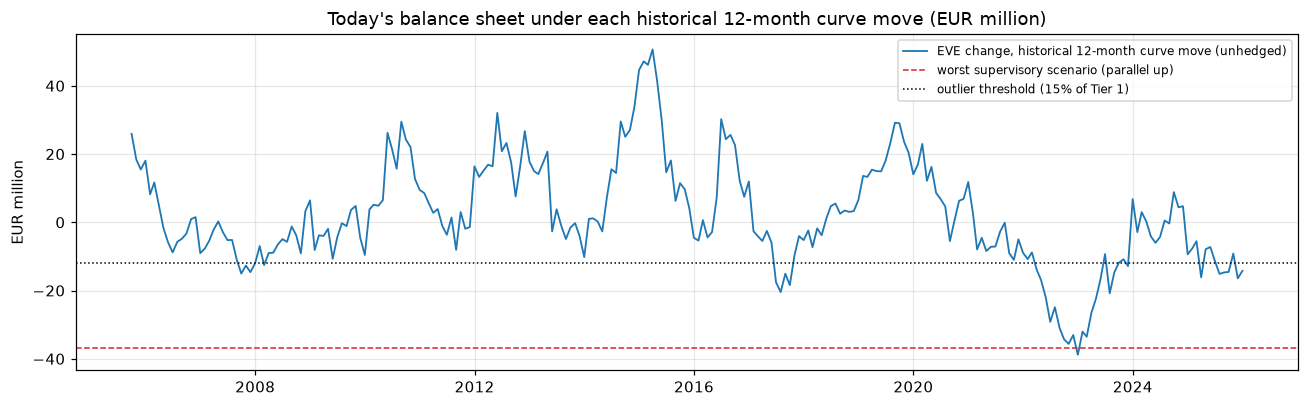

In [12]:
hist = book.historical_eve_changes(zero, monthly, months=12)
q = hist.quantile([0.01, 0.05, 0.5])
display(pd.Series({"observations": len(hist), "1% quantile": q[0.01], "5% quantile": q[0.05], "median": q[0.5],
                   "worst": hist.min(), "worst 12 months ending": f"{hist.idxmin():%B %Y}",
                   "worst supervisory scenario": eve.min()}, name="historical 12-month EVE change").to_frame())

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(hist.index, hist, lw=1.2, label="EVE change, historical 12-month curve move (unhedged)")
ax.axhline(eve.min(), color="C3", ls="--", lw=1, label=f"worst supervisory scenario ({worst})")
ax.axhline(-banking_book.EVE_OUTLIER_THRESHOLD * book.tier1, color="k", ls=":", lw=1, label="outlier threshold (15% of Tier 1)")
ax.set(title="Today's balance sheet under each historical 12-month curve move (EUR million)", ylabel="EUR million")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "historical_eve.png", dpi=150)

### 6.6 Hedging with interest-rate swaps: minimax linear programmes

Par swaps at 2, 5, 10 and 20 years are added to the book. EVE changes are linear in the swap notionals, so the notionals that
**maximise the worst EVE change over a set of scenarios** solve a linear programme. Four designs are compared:

| design | instruments | scenarios in the optimisation |
| --- | --- | --- |
| A | pay-fixed swaps only (the textbook "swap the mortgage book") | six BCBS scenarios |
| B | pay- or receive-fixed swaps | six BCBS scenarios |
| C | pay- or receive-fixed swaps, gross-notional penalty 0.1% | six BCBS + 244 historical 12-month moves |
| D | pay- or receive-fixed swaps, gross-notional penalty 1% | six BCBS + 244 historical 12-month moves |

The penalty is the worst-case EVE (EUR) the committee is willing to give up per EUR of gross notional: it trades residual risk
for a simpler hedge. Every design is then evaluated on both the supervisory scenarios and the historical moves, and on NII.

Swap notionals in EUR million (positive = pay fixed, negative = receive fixed); risk in % of Tier 1


,2y,5y,10y,20y,gross notional,worst BCBS (% T1),worst historical (% T1),1% historical quantile (% T1),NII +200bp (% T1),NII -200bp (% T1)
unhedged,0.000,0.000,0.000,0.000,0.000,-45.900,-48.500,-42.500,1.300,-1.400
"A: pay-fixed, BCBS",0.000,0.000,0.000,146.900,146.900,-9.200,-17.100,-13.700,4.100,-4.200
"B: pay/receive, BCBS",-600.000,10.100,600.000,-143.500,"1,353.700",-0.400,-18.500,-14.900,-1.200,1.100
"C: pay/receive, BCBS + history, penalty 0.1%",-152.300,-248.800,361.800,19.700,782.700,-2.900,-2.900,-2.500,1.000,-1.000
"D: pay/receive, BCBS + history, penalty 1%",-191.900,0.000,0.000,158.700,350.500,-5.800,-5.800,-4.500,0.700,-0.800


,unhedged,A,D
parallel up,-36.700,-1.050,-4.680
parallel down,43.760,-7.360,-4.680
steepener,-24.140,-7.360,-4.290
flattener,16.840,4.460,0.660
short rates up,5.190,6.110,1.620
short rates down,-5.450,-6.420,-1.760


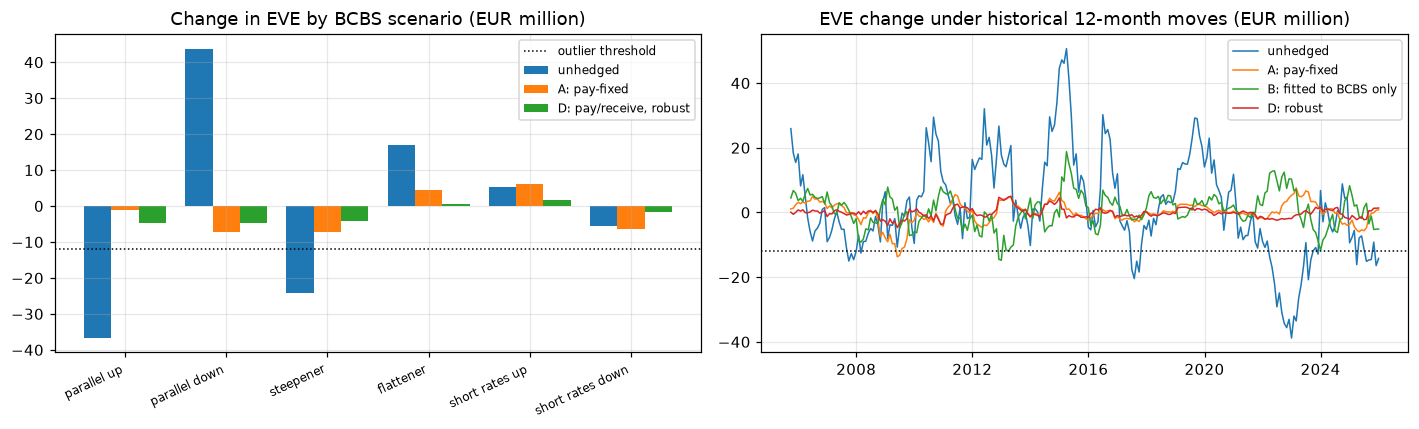

In [13]:
TENORS = (2, 5, 10, 20)
designs = {
    "A: pay-fixed, BCBS": dict(),
    "B: pay/receive, BCBS": dict(allow_receive=True, penalty=1e-4),
    "C: pay/receive, BCBS + history, penalty 0.1%": dict(allow_receive=True, penalty=1e-3, svensson_monthly=monthly),
    "D: pay/receive, BCBS + history, penalty 1%": dict(allow_receive=True, penalty=1e-2, svensson_monthly=monthly),
}
hedges = {name: banking_book.minimax_hedge(book, zero, TENORS, **kw) for name, kw in designs.items()}
rows = {"unhedged": {**{f"{y}y": 0.0 for y in TENORS}, "gross notional": 0.0,
                     "worst BCBS (% T1)": 100 * eve.min() / book.tier1, "worst historical (% T1)": 100 * hist.min() / book.tier1,
                     "1% historical quantile (% T1)": 100 * hist.quantile(0.01) / book.tier1,
                     "NII +200bp (% T1)": 100 * nii["parallel up"] / book.tier1,
                     "NII -200bp (% T1)": 100 * nii["parallel down"] / book.tier1}}
for name, res in hedges.items():
    h = res.get("historical")
    if h is None:
        h = book.historical_eve_changes(zero, monthly, swaps=res["swaps"])
        res["historical"] = h
    rows[name] = {**res["notionals"].to_dict(), "gross notional": res["gross_notional"],
                  "worst BCBS (% T1)": 100 * res["eve"].min() / book.tier1, "worst historical (% T1)": 100 * h.min() / book.tier1,
                  "1% historical quantile (% T1)": 100 * h.quantile(0.01) / book.tier1,
                  "NII +200bp (% T1)": 100 * res["nii"]["parallel up"] / book.tier1,
                  "NII -200bp (% T1)": 100 * res["nii"]["parallel down"] / book.tier1}
designs_table = pd.DataFrame(rows).T
print("Swap notionals in EUR million (positive = pay fixed, negative = receive fixed); risk in % of Tier 1")
display(designs_table.round(1))

CHOSEN = "D: pay/receive, BCBS + history, penalty 1%"
hedge = hedges[CHOSEN]
swaps = [(n, y) for n, y in hedge["swaps"] if abs(n) > 0.05]
compare = pd.DataFrame({"unhedged": eve, "A": hedges["A: pay-fixed, BCBS"]["eve"], "D": hedge["eve"]})
display(compare.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(6)
for i, (label, col) in enumerate([("unhedged", "unhedged"), ("A: pay-fixed", "A"), ("D: pay/receive, robust", "D")]):
    axes[0].bar(x + (i - 1) * 0.27, compare[col], 0.27, label=label)
axes[0].axhline(-banking_book.EVE_OUTLIER_THRESHOLD * book.tier1, color="k", ls=":", lw=1, label="outlier threshold")
axes[0].set_xticks(x, compare.index, rotation=25, ha="right", fontsize=8)
axes[0].set(title="Change in EVE by BCBS scenario (EUR million)")
axes[0].legend(fontsize=8)
axes[1].plot(hist.index, hist, lw=1.0, label="unhedged")
for name, lab in [("A: pay-fixed, BCBS", "A: pay-fixed"), ("B: pay/receive, BCBS", "B: fitted to BCBS only"), (CHOSEN, "D: robust")]:
    axes[1].plot(hedges[name]["historical"].index, hedges[name]["historical"], lw=1.0, label=lab)
axes[1].axhline(-banking_book.EVE_OUTLIER_THRESHOLD * book.tier1, color="k", ls=":", lw=1)
axes[1].set(title="EVE change under historical 12-month moves (EUR million)")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "hedge.png", dpi=150)

### 6.7 Model risk: deposit behaviour

The largest liability, non-maturity deposits, has no contractual maturity: its EVE depends on the behavioural share of core
deposits and on how long they are assumed to stay. The table reports the worst EVE change (% of Tier 1) for alternative
assumptions, unhedged and with the hedge chosen above (kept fixed).

In [14]:
rows = {}
for core_share in (0.5, 0.7, 0.9):
    for core_years in (5, 7, 10):
        alt = banking_book.BankBook(core_share=core_share, core_years=core_years)
        rows[(f"{100 * core_share:.0f}% core", f"{core_years} years")] = {
            "average maturity of all deposits (years)": core_share * (core_years / 2 + 1 / 24),
            "unhedged": 100 * alt.delta_eve(zero).min() / alt.tier1,
            "with chosen hedge": 100 * alt.delta_eve(zero, swaps).min() / alt.tier1,
            "worst scenario (hedged)": alt.delta_eve(zero, swaps).idxmin()}
sens = pd.DataFrame(rows).T
sens.index.names = ["core share", "core horizon"]
display(sens)

average maturity of all deposits (years) unhedged  \
core share core horizon                                                     
50% core   5 years                                         1.271  -59.242   
           7 years                                         1.771  -54.160   
           10 years                                        2.521  -47.698   
70% core   5 years                                         1.779  -52.988   
           7 years                                         2.479  -45.873   
           10 years                                        3.529  -36.826   
90% core   5 years                                         2.288  -46.733   
           7 years                                         3.188  -37.585   
           10 years                                        4.538  -25.954   

                        with chosen hedge worst scenario (hedged)  
core share core horizon                                            
50% core   5 years                -19.215             parallel up  
           7 years                -14.133             parallel up  
           10 years                -7.671             parallel up  
70% core   5 years                -12.960             parallel up  
           7 years                 -5.845           parallel down  
           10 years               -17.383           parallel down  
90% core   5 years                 -9.406               steepener  
           7 years                -14.935           parallel down  
           10 years               -29.770           parallel down

## 7. Conclusions for the ALCO

Results on the official ECB curve, September 2004 - December 2025 (in synthetic mode the numbers differ).

**Curve dynamics.**

- Three principal components explain 97.5% of the variance of monthly yield changes (level 75.6%, slope 16.4%,
  curvature 5.4%). The first component is not a parallel shift: the 3-month rate loads about a third as much as the 10-year
  rate, because for years the policy rate was pinned at the lower bound while long rates moved. The slope and curvature
  components correlate 0.97 and 0.88 with the Nelson-Siegel loadings, so a three-factor Nelson-Siegel model is adequate.
- With free measurement variances the state-space likelihood is degenerate (three maturities end up observed with less than
  1 bp of error and the gradient does not vanish). With a common measurement error (8.9 bp) the maximum is interior and
  well identified: $\lambda = 0.49$ per year (s.e. 0.006), so the curvature loading peaks at about 44 months, later than the
  30 months of Diebold and Li's US data. The factors are very persistent (level autoregressive coefficient 0.991; the two
  dominant modes have a half-life of about 37 months). The C++ filter evaluates the likelihood about 100 times faster than
  NumPy (0.3 ms), so a full estimation takes about 2 seconds and the 11 re-estimations of the forecasting exercise 15 seconds.

**Forecasting.**

- Over 2015-2025 no Nelson-Siegel variant beats the random walk significantly at any horizon or maturity; at one month the
  random walk is significantly better at most maturities (Diebold-Mariano statistics up to +5.5).
- The ranking depends on the regime. In 2015-2021 the models' mean reversion pulled forecasts towards the higher rates of the
  estimation sample and 12-month errors were 1.1 to 6 times those of the random walk. In 2022-2025 mean reversion helped:
  the VAR(1) and state-space models matched or beat the random walk at 6 and 12 months (12-month RMSE ratios 0.78 at
  3 months and 0.88-1.00 elsewhere).
- For the ALCO: the balance sheet should not be steered on point forecasts of rates. Dynamic Nelson-Siegel models are useful
  for decomposition and for generating coherent scenarios, but their forecasts are regime-dependent and not reliably better
  than no change.

**Interest-rate risk in the banking book.**

- The stylised bank loses EUR 36.7 million of economic value in the parallel-up scenario, **45.9% of Tier 1**, three times the
  15% outlier threshold: fixed-rate mortgages (-51.5) and government bonds (-27.0) are only partly offset by deposits (+23.2),
  senior bonds (+13.9) and term deposits (+5.8). Its NII sensitivity is small (about 1.4% of Tier 1): the bank looks safe on
  earnings but not on value, the typical profile of long fixed-rate assets funded by sticky deposits.
- The supervisory calibration is not excessive: the worst historical 12-month move of the ECB curve (the year to December
  2022) would have cost today's book EUR 38.8 million, slightly more than the parallel-up shock. The EBA floor does not bind at
  December 2025 rates; on the December 2020 curve it would cut the parallel-down gain from 71.5 to 13.0 million.
- **Hedging.** Paying fixed on a 20-year swap (design A) brings the supervisory worst case to 9.2% of Tier 1, but leaves 17.1%
  in the worst historical year and costs 4.2% of Tier 1 of NII when rates fall, close to the 5% NII test. Optimising pay and
  receive swaps on the six supervisory scenarios alone (design B) **overfits**: 0.4% on the scenarios, 18.5% on history, with
  EUR 1.35 billion of gross notional. Adding the historical moves to the optimisation gives hedges that are robust on both sets:
  design C (four swaps, EUR 783 million gross) limits the worst loss to 2.9% of Tier 1; design D, **receive fixed on EUR 192
  million at 2 years and pay fixed on EUR 159 million at 20 years**, keeps it at 5.8% with less than half the notional and an
  NII sensitivity below 1% of Tier 1. We recommend design D.
- **Model risk.** The deposit model drives the answer. Across core shares of 50-90% and core horizons of 5-10 years the
  unhedged worst loss ranges from 26% to 59% of Tier 1; with design D held fixed it ranges from 6% to 30%. If deposits are
  stickier than assumed, the hedge overshoots and the bank becomes exposed to falling rates. The hedge should be sized
  together with the validation of the deposit model, and possibly built in stages.

**Limitations.** AAA government curve instead of the €STR swap curve (no basis risk between swap and balance-sheet rates);
static balance sheet and constant prepayment and deposit behaviour within each scenario; commercial margins included in the
cash flows; NII by repricing gap without deposit pass-through; no credit spread risk (CSRBB) and no automatic options; swap
transaction costs and collateral ignored.